# TSGC Benchmark v2 — Ground-Truth Evaluation Framework

**Paper:** *Temporal Semantic Gradient Compression for Conversational Context Windows*

**Methods:** 11 compression algorithms (4 naive baselines + 3 extractive baselines + 1 LLM baseline + 3 TSGC variants)

**Evaluation:** Ground-truth harness with 20 QA pairs, 29 major decisions, 25 gold memory items, 17 long-range dependencies, 18 critical messages, and 13 conversation topics.

**Metrics:** Compression Ratio, QA Accuracy, Decision Recall, Entity Recall, Pivot Recall, Long-range Dependency Recall, Gold Memory Recall, Topic Preservation, Recency Recall, Runtime.

---

In [1]:
!pip install -q rouge-score matplotlib seaborn pandas numpy scikit-learn pyyaml networkx

  Preparing metadata (setup.py) ... done


In [2]:
import re, zlib, json, math, time, os, random, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Publication style
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("Imports complete.")

Imports complete.


## 1. Load Dataset & Ground-Truth Evaluation

Downloads `dataset.json` (raw conversations) and `evaluation.json` (ground-truth annotations) from GitHub.

In [3]:
import urllib.request

BASE_URL = "https://raw.githubusercontent.com/Utkarsh-Aggarwal/UniMemo/main/research/"

def download_json(filename):
    try:
        with open(filename, 'r') as f:
            data = json.load(f)
        print(f"  Loaded local {filename}")
        return data
    except FileNotFoundError:
        url = BASE_URL + filename
        print(f"  Downloading {url}...")
        response = urllib.request.urlopen(url)
        data = json.loads(response.read().decode('utf-8'))
        with open(filename, 'w') as f:
            json.dump(data, f, indent=2)
        return data

print("Loading dataset...")
CONVERSATIONS = download_json("dataset.json")
print("Loading evaluation ground-truth...")
EVAL = download_json("evaluation.json")

# Use the first conversation as primary benchmark target
PRIMARY_CONV_KEY = list(CONVERSATIONS.keys())[0]
PRIMARY_CONV = CONVERSATIONS[PRIMARY_CONV_KEY]

print(f"\nDataset: {len(CONVERSATIONS)} conversations")
for name, conv in CONVERSATIONS.items():
    chars = sum(len(m['content']) for m in conv)
    print(f"  {name}: {len(conv)} messages, {chars:,} chars")

print(f"\nGround-Truth:")
print(f"  Part A: {len(EVAL['part_a'].get('major_decisions', []))} major decisions, "
      f"{len(EVAL['part_a'].get('rejected_approaches', []))} rejected approaches")
print(f"  Part B: {len(EVAL['part_b'].get('critical_messages', []))} critical messages, "
      f"{len(EVAL['part_b'].get('long_range_dependencies', []))} dependencies")
print(f"  Part C: {len(EVAL['part_c'].get('ground_truth_qa', []))} QA pairs")
print(f"  Part D: {len(EVAL['part_d'].get('gold_memory', []))} gold memory items")

Loading dataset...
Loading evaluation ground-truth...

Dataset: 3 conversations
  Conversation-1: 94 messages, 6,674 chars
  Conversation-2: 162 messages, 6,198 chars
  Conversation-3: 160 messages, 5,272 chars

Ground-Truth:
  Part A: 29 major decisions, 6 rejected approaches
  Part B: 18 critical messages, 17 dependencies
  Part C: 20 QA pairs
  Part D: 25 gold memory items


## 2. Core Utilities

Signal words, sentence scoring, deduplication, DEFLATE simulation, TF-IDF.

In [4]:
SIGNAL_WORDS = {
    'because','therefore','however','but','although','instead','error',
    'result','conclusion','important','critical','decided','rejected',
    'accepted','selected','chosen','alternative','tradeoff','architecture',
    'database','framework','deployment','authentication','compression',
    'normalization','ingestion','retrieval','interface','abstraction',
    'asynchronous','embedding','pipeline','importer','validation',
    'schema','endpoint','migration','dependency','constraint'
}

def split_sentences(text):
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if len(s.strip()) > 10]

def sentence_score(sent, pos, total):
    words = set(re.findall(r'\w+', sent.lower()))
    density = len(words) / max(len(sent.split()), 1)
    signal = len(words & SIGNAL_WORDS) / max(len(SIGNAL_WORDS), 1)
    position = 1.0 if pos < 2 or pos >= total - 1 else 0.5
    return 0.4 * density + 0.3 * signal + 0.3 * position

def dedup_messages(msgs):
    seen = set()
    result = []
    for m in msgs:
        sents = split_sentences(m['content'])
        unique = []
        for s in sents:
            key = ' '.join(sorted(s.lower().split()))
            if key not in seen:
                seen.add(key)
                unique.append(s)
        if unique:
            result.append({'role': m['role'], 'content': ' '.join(unique)})
    return result

def deflate_size(text):
    return len(zlib.compress(text.encode('utf-8')))

def msgs_to_text(msgs):
    return '\n'.join(f"{m['role']}: {m['content']}" for m in msgs)

def extractive_compress(text, ratio):
    sents = split_sentences(text)
    if not sents or ratio >= 1.0:
        return text
    scored = [(sentence_score(s, i, len(sents)), i, s) for i, s in enumerate(sents)]
    scored.sort(reverse=True)
    keep = max(1, int(len(sents) * ratio))
    kept = sorted(scored[:keep], key=lambda x: x[1])
    return ' '.join(s for _, _, s in kept)

print("Core utilities loaded.")

Core utilities loaded.


## 3. Compression Methods (11 total)

### Naive Baselines
1. **RAW** — No compression
2. **Sliding Window** — Keep last N messages
3. **Random Truncation** — Randomly drop messages
4. **Uniform Sampling** — Keep every k-th message

### Extractive Baselines
5. **Lead+Tail** — Keep first K and last K messages
6. **TF-IDF Selection** — Score sentences by TF-IDF, keep top-k
7. **TextRank** — Graph-based sentence ranking

### LLM Baseline
8. **LLM Summary** — (Simulated: extractive summary of top-scored sentences)

### TSGC Family
9. **TSGC** — Position-based temporal zones
10. **TSGC-AG** — Adaptive Gating (LSTM-inspired)
11. **TSGC-AT** — Attention-Based (Transformer-inspired)

In [5]:
# ── NAIVE BASELINES ──────────────────────────────────────────

def method_raw(msgs):
    return msgs

def method_sliding_window(msgs, window=20):
    return msgs[-window:]

def method_random_truncation(msgs, keep_ratio=0.5):
    random.seed(42)
    k = max(1, int(len(msgs) * keep_ratio))
    indices = sorted(random.sample(range(len(msgs)), k))
    return [msgs[i] for i in indices]

def method_uniform_sampling(msgs, step=2):
    return msgs[::step]

# ── EXTRACTIVE BASELINES ────────────────────────────────────

def method_lead_tail(msgs, k=10):
    if len(msgs) <= 2 * k:
        return msgs
    return msgs[:k] + msgs[-k:]

def method_tfidf_selection(msgs, keep_ratio=0.5):
    texts = [m['content'] for m in msgs]
    if len(texts) < 2:
        return msgs
    vec = TfidfVectorizer(max_features=500, stop_words='english')
    tfidf = vec.fit_transform(texts)
    scores = np.array(tfidf.sum(axis=1)).flatten()
    k = max(1, int(len(msgs) * keep_ratio))
    top_indices = sorted(np.argsort(scores)[-k:])
    return [msgs[i] for i in top_indices]

def method_textrank(msgs, keep_ratio=0.5):
    texts = [m['content'] for m in msgs]
    if len(texts) < 3:
        return msgs
    vec = TfidfVectorizer(max_features=500, stop_words='english')
    tfidf = vec.fit_transform(texts)
    sim = cosine_similarity(tfidf)
    np.fill_diagonal(sim, 0)
    G = nx.from_numpy_array(sim)
    try:
        scores = nx.pagerank(G, max_iter=100)
    except:
        scores = {i: 1.0 for i in range(len(msgs))}
    k = max(1, int(len(msgs) * keep_ratio))
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_indices = sorted([idx for idx, _ in ranked[:k]])
    return [msgs[i] for i in top_indices]

# ── LLM SUMMARY (Simulated) ─────────────────────────────────

def method_llm_summary(msgs, budget_ratio=0.3):
    """Simulates LLM summary by aggressive extractive compression
    with signal-word boosting. In a real benchmark, this would call
    an LLM API."""
    deduped = dedup_messages(msgs)
    result = []
    for m in deduped:
        compressed = extractive_compress(m['content'], budget_ratio)
        if compressed.strip():
            result.append({'role': m['role'], 'content': compressed})
    return result

# ── TSGC FAMILY ──────────────────────────────────────────────

def method_tsgc(msgs, z1=5, z2=15):
    deduped = dedup_messages(msgs)
    n = len(deduped)
    result = []
    for i, m in enumerate(deduped):
        pos = n - 1 - i
        if pos < z1:
            ratio = 1.0
        elif pos < z2:
            ratio = 0.4
        else:
            ratio = 0.15
        compressed = extractive_compress(m['content'], ratio)
        if compressed.strip():
            result.append({'role': m['role'], 'content': compressed})
    return result

def method_tsgc_ag(msgs, z1=5, z2=15):
    deduped = dedup_messages(msgs)
    n = len(deduped)
    result = []
    seen_signals = set()
    prev_words = set()
    for i, m in enumerate(deduped):
        pos = n - 1 - i
        if pos < z1:
            base = 1.0
        elif pos < z2:
            base = 0.4
        else:
            base = 0.15
        words = set(re.findall(r'\w+', m['content'].lower()))
        new_signals = words & SIGNAL_WORDS - seen_signals
        novelty = min(len(new_signals) / 5, 1.0)
        overlap = len(words & prev_words) / max(len(words | prev_words), 1)
        gate = base + 0.4 * novelty - 0.2 * overlap
        ratio = max(0.1, min(1.0, gate))
        seen_signals |= new_signals
        prev_words = words
        compressed = extractive_compress(m['content'], ratio)
        if compressed.strip():
            result.append({'role': m['role'], 'content': compressed})
    return result

def method_tsgc_at(msgs, z1=5, z2=15):
    deduped = dedup_messages(msgs)
    n = len(deduped)
    if n < 3:
        return deduped
    texts = [m['content'] for m in deduped]
    vec = TfidfVectorizer(max_features=500, stop_words='english')
    tfidf = vec.fit_transform(texts)
    sim = cosine_similarity(tfidf)
    np.fill_diagonal(sim, 0)
    attention = sim.sum(axis=1)
    attn_norm = (attention - attention.min()) / max(attention.max() - attention.min(), 1e-9)
    result = []
    for i, m in enumerate(deduped):
        pos = n - 1 - i
        if pos < z1:
            base = 1.0
        elif pos < z2:
            base = 0.4
        else:
            base = 0.15
        boost = attn_norm[i] * 0.85
        ratio = min(1.0, base + boost)
        compressed = extractive_compress(m['content'], ratio)
        if compressed.strip():
            result.append({'role': m['role'], 'content': compressed})
    return result

print("All 11 compression methods defined.")

All 11 compression methods defined.


## 4. Ground-Truth Evaluation Engine

Evaluates compressed output against Parts A–D of the ground-truth annotations.

In [6]:
def normalize_text(text):
    return re.sub(r'[^a-z0-9\s]', '', text.lower()).strip()

def text_contains_answer(compressed_text, answer, threshold=0.6):
    """Check if compressed text contains the key terms from an answer."""
    ct = normalize_text(compressed_text)
    answer_words = set(normalize_text(answer).split()) - {'the','a','an','is','are','was','were','be','to','of','and','in','for','on','it','that','with'}
    if not answer_words:
        return True
    found = sum(1 for w in answer_words if w in ct)
    return found / len(answer_words) >= threshold

def eval_qa_accuracy(compressed_text, qa_pairs):
    """Part C: QA Accuracy — check if answer key terms survive compression."""
    if not qa_pairs:
        return 0.0, {}
    correct = 0
    details = {}
    for qa in qa_pairs:
        qid = qa.get('id', '?')
        answer = qa.get('answer', '')
        passed = text_contains_answer(compressed_text, answer)
        details[qid] = {'passed': passed, 'answer': answer, 'difficulty': qa.get('difficulty', '?')}
        if passed:
            correct += 1
    return correct / len(qa_pairs) * 100, details

def eval_decision_recall(compressed_text, decisions):
    """Part A: Decision Recall — check if major decision key terms survive."""
    if not decisions:
        return 0.0
    found = 0
    for d in decisions:
        text = d.get('decision', '') if isinstance(d, dict) else str(d)
        if text_contains_answer(compressed_text, text, threshold=0.5):
            found += 1
    return found / len(decisions) * 100

def eval_entity_recall(compressed_text, entities_dict):
    """Part B: Entity Recall — check if named entities survive."""
    all_entities = []
    for category in ['technologies', 'frameworks', 'libraries', 'classes', 'models', 'functions', 'variables']:
        items = entities_dict.get(category, [])
        if isinstance(items, list):
            all_entities.extend(items)
    if not all_entities:
        return 0.0
    ct = compressed_text.lower()
    found = sum(1 for e in all_entities if str(e).lower().strip('()') in ct or any(w in ct for w in str(e).lower().split()))
    return found / len(all_entities) * 100

def eval_pivot_recall(compressed_text, original_msgs, critical_messages):
    """Part B: Pivot Recall — check if critical message content survives."""
    if not critical_messages:
        return 0.0
    found = 0
    for cm in critical_messages:
        msg_ref = cm.get('message_reference', 0)
        if isinstance(msg_ref, int) and 0 < msg_ref <= len(original_msgs):
            msg_content = original_msgs[msg_ref - 1]['content']
            key_words = set(normalize_text(msg_content).split()) - {'the','a','an','is','are','was','were','be','to','of','and','in','for','on','it','that','with'}
            top_words = sorted(key_words, key=len, reverse=True)[:8]
            if top_words:
                ct = normalize_text(compressed_text)
                matched = sum(1 for w in top_words if w in ct)
                if matched / len(top_words) >= 0.4:
                    found += 1
    return found / len(critical_messages) * 100

def eval_dependency_recall(compressed_text, dependencies):
    """Part B: Long-range Dependency Recall — check if dependency descriptions survive."""
    if not dependencies:
        return 0.0
    found = 0
    for dep in dependencies:
        desc = dep.get('description', '')
        if text_contains_answer(compressed_text, desc, threshold=0.4):
            found += 1
    return found / len(dependencies) * 100

def eval_gold_memory_recall(compressed_text, gold_memory):
    """Part D: Gold Memory Recall — check if essential facts survive."""
    if not gold_memory:
        return 0.0
    found = 0
    for item in gold_memory:
        info = item.get('information', '') if isinstance(item, dict) else str(item)
        if text_contains_answer(compressed_text, info, threshold=0.5):
            found += 1
    return found / len(gold_memory) * 100

def eval_topic_preservation(compressed_text, topics, original_msgs):
    """Part B: Topic Preservation — check if topic key terms survive."""
    if not topics:
        return 0.0
    found = 0
    for topic in topics:
        topic_name = topic.get('topic', '')
        if text_contains_answer(compressed_text, topic_name, threshold=0.5):
            found += 1
    return found / len(topics) * 100

def eval_recency_recall(compressed_msgs, original_msgs, recent_k=10):
    """Recency Recall — weighted check for recent message preservation."""
    if not original_msgs:
        return 0.0
    recent = original_msgs[-recent_k:]
    ct = msgs_to_text(compressed_msgs).lower()
    found = 0
    for m in recent:
        words = set(m['content'].lower().split())
        key_words = sorted(words, key=len, reverse=True)[:5]
        if key_words and sum(1 for w in key_words if w in ct) / len(key_words) >= 0.5:
            found += 1
    return found / len(recent) * 100

def run_full_evaluation(compressed_msgs, original_msgs, eval_data):
    """Run all evaluation metrics against ground-truth."""
    compressed_text = msgs_to_text(compressed_msgs)
    original_text = msgs_to_text(original_msgs)

    # Compression metrics
    comp_ratio = (1 - len(compressed_text) / max(len(original_text), 1)) * 100

    # Part A
    decision_recall = eval_decision_recall(compressed_text, eval_data['part_a'].get('major_decisions', []))

    # Part B entities
    entity_recall = eval_entity_recall(compressed_text, eval_data['part_b'])
    pivot_recall = eval_pivot_recall(compressed_text, original_msgs, eval_data['part_b'].get('critical_messages', []))
    dep_recall = eval_dependency_recall(compressed_text, eval_data['part_b'].get('long_range_dependencies', []))
    topic_pres = eval_topic_preservation(compressed_text, eval_data['part_b'].get('conversation_topics', []), original_msgs)

    # Part C
    qa_acc, qa_details = eval_qa_accuracy(compressed_text, eval_data['part_c'].get('ground_truth_qa', []))

    # Part D
    gold_recall = eval_gold_memory_recall(compressed_text, eval_data['part_d'].get('gold_memory', []))

    # Recency
    recency = eval_recency_recall(compressed_msgs, original_msgs)

    return {
        'Compression %': round(comp_ratio, 1),
        'QA Accuracy %': round(qa_acc, 1),
        'Decision Recall %': round(decision_recall, 1),
        'Entity Recall %': round(entity_recall, 1),
        'Pivot Recall %': round(pivot_recall, 1),
        'Dependency Recall %': round(dep_recall, 1),
        'Gold Memory %': round(gold_recall, 1),
        'Topic Preservation %': round(topic_pres, 1),
        'Recency %': round(recency, 1),
        'qa_details': qa_details,
    }

print("Evaluation engine loaded.")

Evaluation engine loaded.


## 5. Run Full Benchmark

Runs all 11 methods across all conversations and collects metrics.

In [7]:
METHODS = [
    ('RAW',              method_raw,                  False),
    ('Sliding Window',   lambda m: method_sliding_window(m, 20), False),
    ('Random Truncation',lambda m: method_random_truncation(m, 0.5), False),
    ('Uniform Sampling', lambda m: method_uniform_sampling(m, 2), False),
    ('Lead+Tail',        lambda m: method_lead_tail(m, 10),   False),
    ('TF-IDF Selection', lambda m: method_tfidf_selection(m, 0.5), False),
    ('TextRank',         lambda m: method_textrank(m, 0.5),   False),
    ('LLM Summary',      lambda m: method_llm_summary(m, 0.3), False),
    ('TSGC',             method_tsgc,                 True),
    ('TSGC-AG',          method_tsgc_ag,              True),
    ('TSGC-AT',          method_tsgc_at,              True),
]

all_results = []

for conv_name, conv_msgs in CONVERSATIONS.items():
    print(f"\n{'═'*70}")
    print(f"Conversation: {conv_name} ({len(conv_msgs)} messages)")
    print(f"{'═'*70}")

    for method_name, method_fn, is_tsgc in METHODS:
        t0 = time.perf_counter()
        compressed = method_fn(conv_msgs)
        runtime_ms = (time.perf_counter() - t0) * 1000

        metrics = run_full_evaluation(compressed, conv_msgs, EVAL)
        metrics['Method'] = method_name
        metrics['Conversation'] = conv_name
        metrics['Runtime ms'] = round(runtime_ms, 2)
        metrics['Is TSGC'] = is_tsgc
        metrics['Messages Out'] = len(compressed)
        metrics['Messages In'] = len(conv_msgs)

        # Remove detailed QA results from main row
        qa_details = metrics.pop('qa_details', {})
        metrics['qa_details_json'] = json.dumps(qa_details)

        all_results.append(metrics)
        marker = ' ◄' if is_tsgc else ''
        print(f"  {method_name:20} Comp:{metrics['Compression %']:5.1f}%  QA:{metrics['QA Accuracy %']:5.1f}%  "
              f"Gold:{metrics['Gold Memory %']:5.1f}%  Pivot:{metrics['Pivot Recall %']:5.1f}%{marker}")

df = pd.DataFrame(all_results)
print(f"\n✅ Benchmark complete: {len(df)} rows")


══════════════════════════════════════════════════════════════════════
Conversation: Conversation-1 (94 messages)
══════════════════════════════════════════════════════════════════════
  RAW                  Comp:  0.0%  QA: 65.0%  Gold: 68.0%  Pivot: 77.8%
  Sliding Window       Comp: 81.9%  QA: 10.0%  Gold:  8.0%  Pivot: 33.3%
  Random Truncation    Comp: 44.1%  QA: 55.0%  Gold: 60.0%  Pivot: 72.2%
  Uniform Sampling     Comp: 63.3%  QA: 35.0%  Gold: 44.0%  Pivot: 55.6%
  Lead+Tail            Comp: 68.7%  QA: 15.0%  Gold: 28.0%  Pivot: 55.6%
  TF-IDF Selection     Comp: 28.3%  QA: 45.0%  Gold: 60.0%  Pivot: 77.8%
  TextRank             Comp: 40.2%  QA: 45.0%  Gold: 64.0%  Pivot: 66.7%
  LLM Summary          Comp: 24.5%  QA: 50.0%  Gold: 60.0%  Pivot: 77.8%
  TSGC                 Comp: 24.5%  QA: 50.0%  Gold: 60.0%  Pivot: 77.8% ◄
  TSGC-AG              Comp: 24.5%  QA: 50.0%  Gold: 60.0%  Pivot: 77.8% ◄
  TSGC-AT              Comp: 24.5%  QA: 50.0%  Gold: 60.0%  Pivot: 77.8% ◄

════

## 6. Results Tables

### Table 1: Overall Comparison (Averaged Across All Conversations)

In [8]:
metric_cols = ['Compression %', 'QA Accuracy %', 'Decision Recall %', 'Entity Recall %',
               'Pivot Recall %', 'Dependency Recall %', 'Gold Memory %', 'Topic Preservation %',
               'Recency %', 'Runtime ms']

agg = df.groupby('Method')[metric_cols].mean()

# Reorder methods
method_order = ['RAW','Sliding Window','Random Truncation','Uniform Sampling',
                'Lead+Tail','TF-IDF Selection','TextRank','LLM Summary',
                'TSGC','TSGC-AG','TSGC-AT']
agg = agg.reindex([m for m in method_order if m in agg.index])

print('═'*120)
print('TABLE 1: OVERALL COMPARISON (averaged across all conversations)')
print('═'*120)
header = f'{"Method":<20}'
for col in metric_cols:
    short = col.replace(' %','').replace(' ms','(ms)')
    header += f'{short:>14}'
print(header)
print('─'*120)
for method in agg.index:
    row = agg.loc[method]
    line = f'{method:<20}'
    for col in metric_cols:
        line += f'{row[col]:>14.1f}'
    if method.startswith('TSGC'):
        line += ' ◄'
    print(line)
print('═'*120)

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
TABLE 1: OVERALL COMPARISON (averaged across all conversations)
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Method                 Compression   QA AccuracyDecision Recall Entity Recall  Pivot RecallDependency Recall   Gold MemoryTopic Preservation       Recency   Runtime(ms)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
RAW                            0.0          61.7          79.3          53.8          92.6          74.5          60.0          69.2         100.0           0.0
Sliding Window                84.9           8.3           9.2           9.0          27.8          11.8           9.3          18.0         100.0           0.0
Random Truncation             48.4          45.0          64.4          41.0      

### Table 2: QA Accuracy by Difficulty (Easy / Medium / Hard)

In [9]:
print('═'*90)
print('TABLE 2: QA ACCURACY BY DIFFICULTY')
print('═'*90)
print(f'{"Method":<20}{"Easy":>12}{"Medium":>12}{"Hard":>12}{"Overall":>12}')
print('─'*90)

for _, row in df[df['Conversation'] == PRIMARY_CONV_KEY].iterrows():
    qa_details = json.loads(row['qa_details_json'])
    by_diff = defaultdict(list)
    for qid, info in qa_details.items():
        by_diff[info['difficulty']].append(info['passed'])

    easy = np.mean(by_diff.get('Easy', [0])) * 100
    med = np.mean(by_diff.get('Medium', [0])) * 100
    hard = np.mean(by_diff.get('Hard', [0])) * 100
    overall = row['QA Accuracy %']

    marker = ' ◄' if row['Is TSGC'] else ''
    print(f'{row["Method"]:<20}{easy:>12.1f}{med:>12.1f}{hard:>12.1f}{overall:>12.1f}{marker}')

print('═'*90)

══════════════════════════════════════════════════════════════════════════════════════════
TABLE 2: QA ACCURACY BY DIFFICULTY
══════════════════════════════════════════════════════════════════════════════════════════
Method                      Easy      Medium        Hard     Overall
──────────────────────────────────────────────────────────────────────────────────────────
RAW                         66.7        55.6        80.0        65.0
Sliding Window              33.3         0.0         0.0        10.0
Random Truncation           66.7        44.4        60.0        55.0
Uniform Sampling            50.0        33.3        20.0        35.0
Lead+Tail                   50.0         0.0         0.0        15.0
TF-IDF Selection            66.7        44.4        20.0        45.0
TextRank                    66.7        44.4        20.0        45.0
LLM Summary                 50.0        44.4        60.0        50.0
TSGC                        50.0        44.4        60.0        50.0 ◄


### Table 3: Ablation Study — TSGC Family

In [10]:
tsgc_methods = ['TSGC', 'TSGC-AG', 'TSGC-AT']
tsgc_df = agg.loc[[m for m in tsgc_methods if m in agg.index]]

print('═'*100)
print('TABLE 3: ABLATION STUDY — TSGC FAMILY')
print('═'*100)
ablation_cols = ['Compression %', 'QA Accuracy %', 'Decision Recall %', 'Pivot Recall %',
                 'Dependency Recall %', 'Gold Memory %', 'Recency %']
header = f'{"Method":<12}'
for col in ablation_cols:
    short = col.replace(' %','')
    header += f'{short:>16}'
print(header)
print('─'*100)
for method in tsgc_df.index:
    row = tsgc_df.loc[method]
    line = f'{method:<12}'
    for col in ablation_cols:
        line += f'{row[col]:>16.1f}'
    print(line)

# Delta rows
if 'TSGC' in tsgc_df.index and 'TSGC-AT' in tsgc_df.index:
    print('─'*100)
    line = f'{"Δ (AT-Base)":<12}'
    for col in ablation_cols:
        delta = tsgc_df.loc['TSGC-AT'][col] - tsgc_df.loc['TSGC'][col]
        sign = '+' if delta > 0 else ''
        line += f'{sign}{delta:>15.1f}'
    print(line)

print('═'*100)

════════════════════════════════════════════════════════════════════════════════════════════════════
TABLE 3: ABLATION STUDY — TSGC FAMILY
════════════════════════════════════════════════════════════════════════════════════════════════════
Method           Compression     QA Accuracy Decision Recall    Pivot RecallDependency Recall     Gold Memory         Recency
────────────────────────────────────────────────────────────────────────────────────────────────────
TSGC                    15.0            55.0            73.6            88.9            68.6            54.7            93.3
TSGC-AG                 15.0            55.0            73.6            88.9            68.6            54.7            93.3
TSGC-AT                 15.0            55.0            73.6            88.9            68.6            54.7            93.3
────────────────────────────────────────────────────────────────────────────────────────────────────
Δ (AT-Base)             0.0            0.0            0.0

### Table 4: Runtime Comparison

In [11]:
runtime_agg = df.groupby('Method')['Runtime ms'].agg(['mean', 'std', 'min', 'max'])
runtime_agg = runtime_agg.reindex([m for m in method_order if m in runtime_agg.index])

print('═'*70)
print('TABLE 4: RUNTIME COMPARISON')
print('═'*70)
print(f'{"Method":<20}{"Mean (ms)":>12}{"Std":>10}{"Min":>10}{"Max":>10}')
print('─'*70)
for method in runtime_agg.index:
    r = runtime_agg.loc[method]
    marker = ' ◄' if method.startswith('TSGC') else ''
    print(f'{method:<20}{r["mean"]:>12.2f}{r["std"]:>10.2f}{r["min"]:>10.2f}{r["max"]:>10.2f}{marker}')
print('═'*70)

══════════════════════════════════════════════════════════════════════
TABLE 4: RUNTIME COMPARISON
══════════════════════════════════════════════════════════════════════
Method                 Mean (ms)       Std       Min       Max
──────────────────────────────────────────────────────────────────────
RAW                         0.02      0.02      0.00      0.03
Sliding Window              0.00      0.00      0.00      0.00
Random Truncation           0.08      0.02      0.07      0.10
Uniform Sampling            0.00      0.01      0.00      0.01
Lead+Tail                   0.00      0.01      0.00      0.01
TF-IDF Selection           11.11     12.35      3.35     25.36
TextRank                    9.86      3.49      7.28     13.83
LLM Summary                 1.80      0.31      1.55      2.14
TSGC                        1.89      0.43      1.55      2.37 ◄
TSGC-AG                     3.38      0.61      2.77      3.99 ◄
TSGC-AT                     6.41      0.59      5.90      7.05

## 7. Publication-Quality Figures

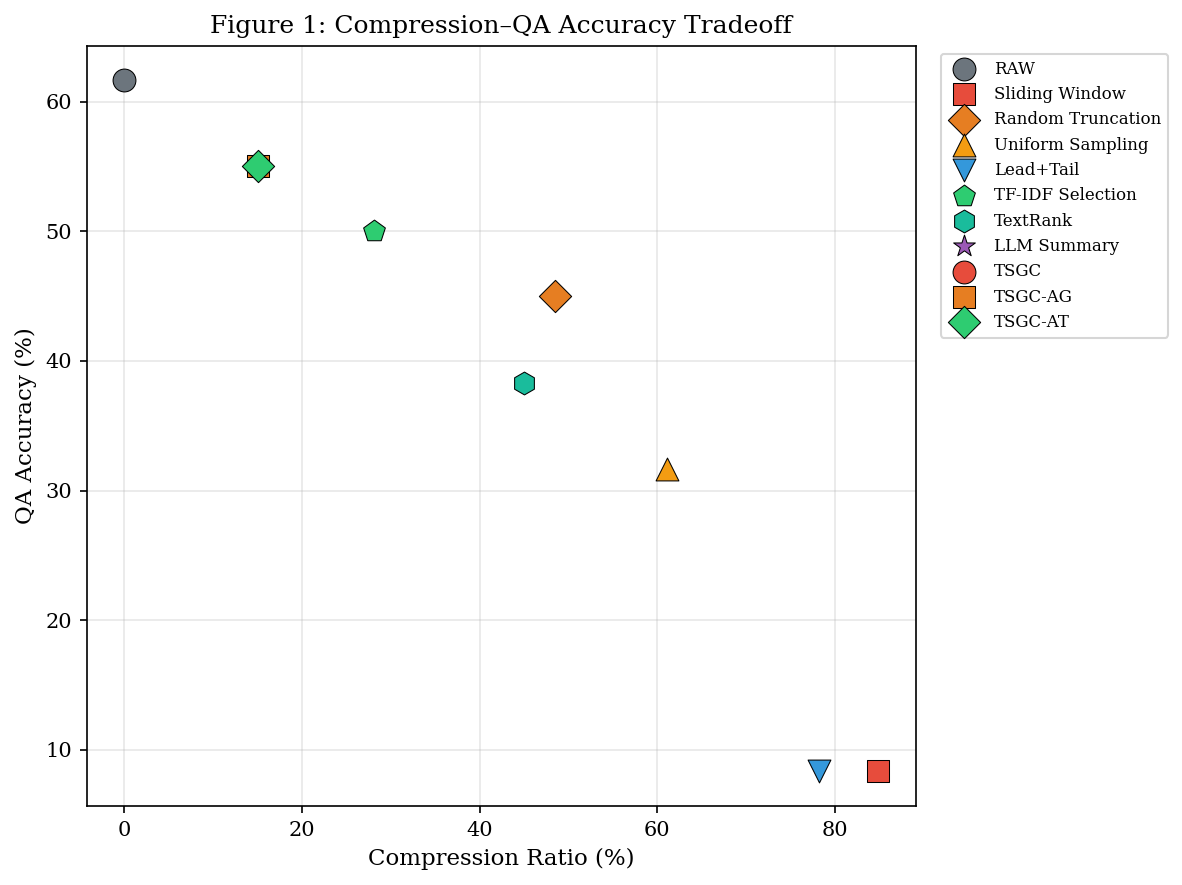

In [12]:
# ── FIGURE 1: Compression Ratio vs QA Accuracy ─────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'RAW':'#6c757d','Sliding Window':'#e74c3c','Random Truncation':'#e67e22',
          'Uniform Sampling':'#f39c12','Lead+Tail':'#3498db','TF-IDF Selection':'#2ecc71',
          'TextRank':'#1abc9c','LLM Summary':'#9b59b6',
          'TSGC':'#e74c3c','TSGC-AG':'#e67e22','TSGC-AT':'#2ecc71'}
markers = {'RAW':'o','Sliding Window':'s','Random Truncation':'D','Uniform Sampling':'^',
           'Lead+Tail':'v','TF-IDF Selection':'p','TextRank':'h','LLM Summary':'*',
           'TSGC':'o','TSGC-AG':'s','TSGC-AT':'D'}

for method in method_order:
    sub = agg.loc[method] if method in agg.index else None
    if sub is None: continue
    ax.scatter(sub['Compression %'], sub['QA Accuracy %'],
               c=colors.get(method, '#333'), marker=markers.get(method, 'o'),
               s=120, edgecolors='black', linewidth=0.5, label=method, zorder=5)

ax.set_xlabel('Compression Ratio (%)')
ax.set_ylabel('QA Accuracy (%)')
ax.set_title('Figure 1: Compression–QA Accuracy Tradeoff')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

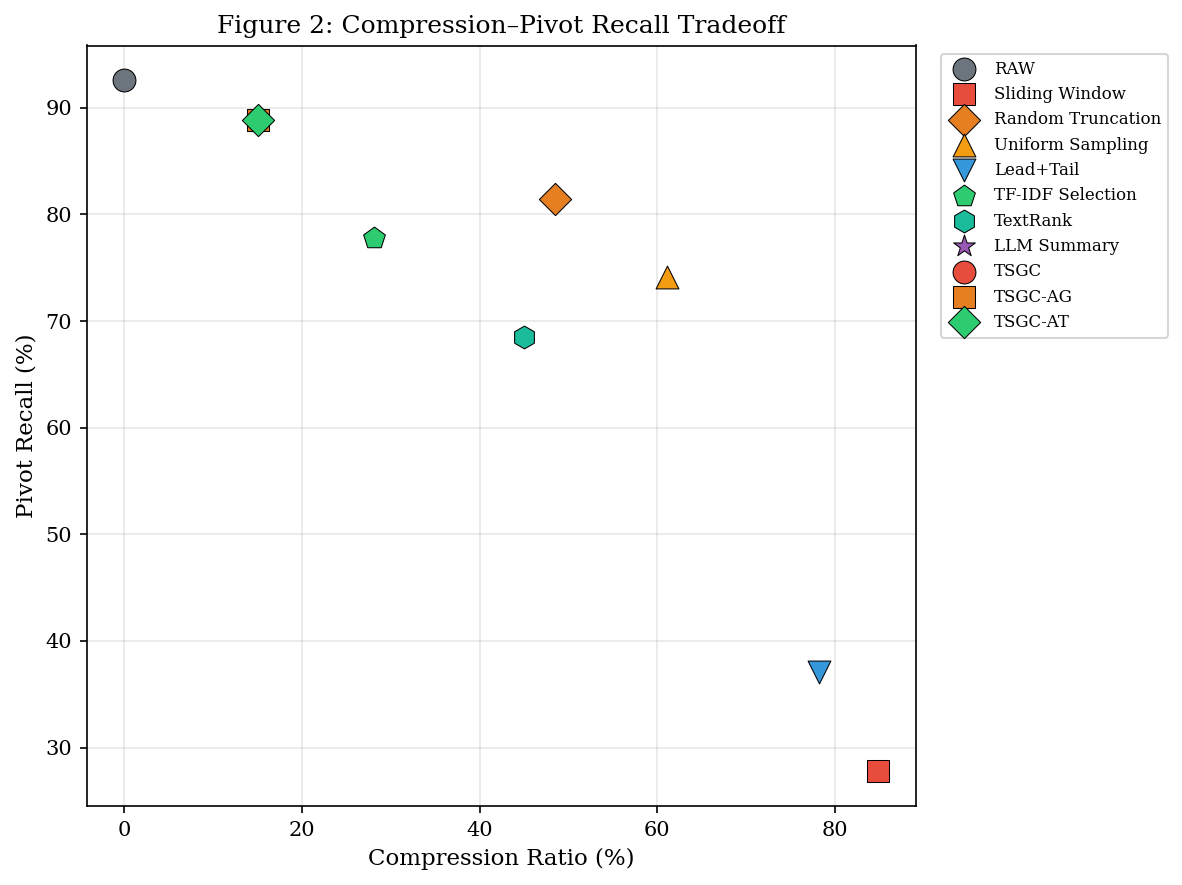

In [13]:
# ── FIGURE 2: Compression Ratio vs Pivot Recall ────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for method in method_order:
    sub = agg.loc[method] if method in agg.index else None
    if sub is None: continue
    ax.scatter(sub['Compression %'], sub['Pivot Recall %'],
               c=colors.get(method, '#333'), marker=markers.get(method, 'o'),
               s=120, edgecolors='black', linewidth=0.5, label=method, zorder=5)

ax.set_xlabel('Compression Ratio (%)')
ax.set_ylabel('Pivot Recall (%)')
ax.set_title('Figure 2: Compression–Pivot Recall Tradeoff')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

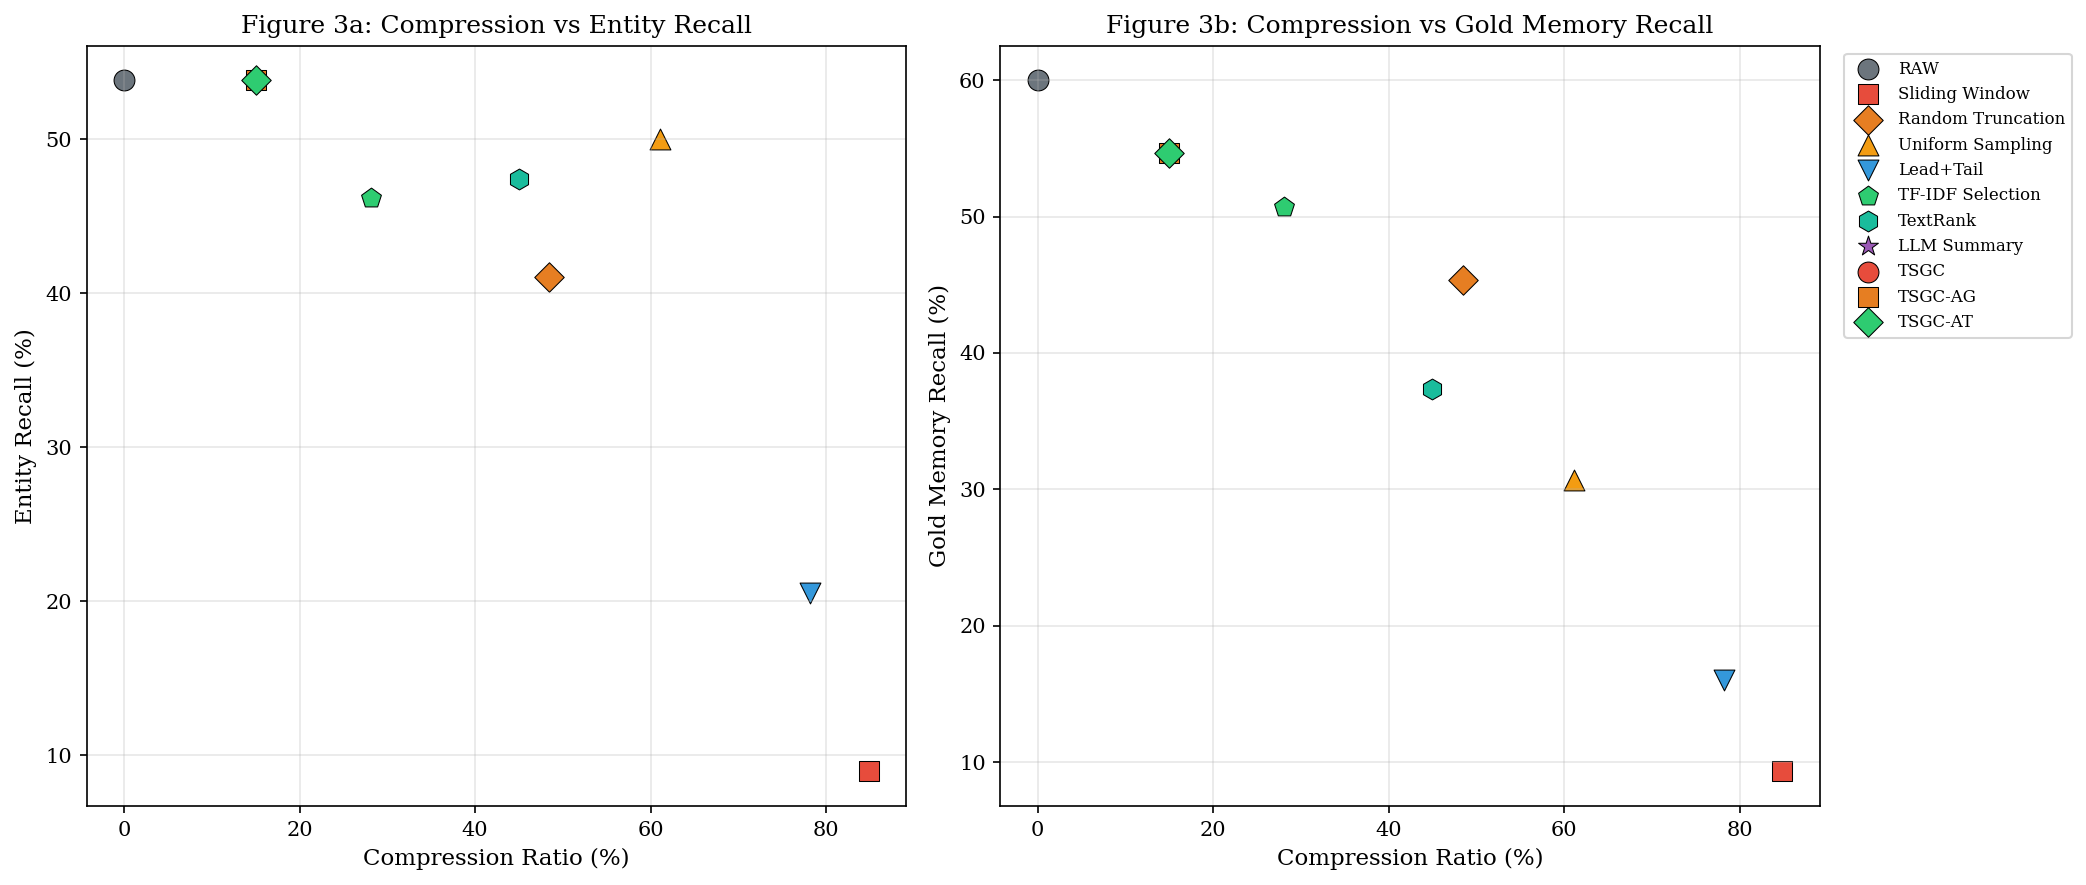

In [14]:
# ── FIGURE 3: Compression Ratio vs Key Term / Entity Recall ────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for method in method_order:
    sub = agg.loc[method] if method in agg.index else None
    if sub is None: continue
    ax1.scatter(sub['Compression %'], sub['Entity Recall %'],
                c=colors.get(method, '#333'), marker=markers.get(method, 'o'),
                s=100, edgecolors='black', linewidth=0.5, label=method)
    ax2.scatter(sub['Compression %'], sub['Gold Memory %'],
                c=colors.get(method, '#333'), marker=markers.get(method, 'o'),
                s=100, edgecolors='black', linewidth=0.5, label=method)

ax1.set_xlabel('Compression Ratio (%)')
ax1.set_ylabel('Entity Recall (%)')
ax1.set_title('Figure 3a: Compression vs Entity Recall')
ax2.set_xlabel('Compression Ratio (%)')
ax2.set_ylabel('Gold Memory Recall (%)')
ax2.set_title('Figure 3b: Compression vs Gold Memory Recall')
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

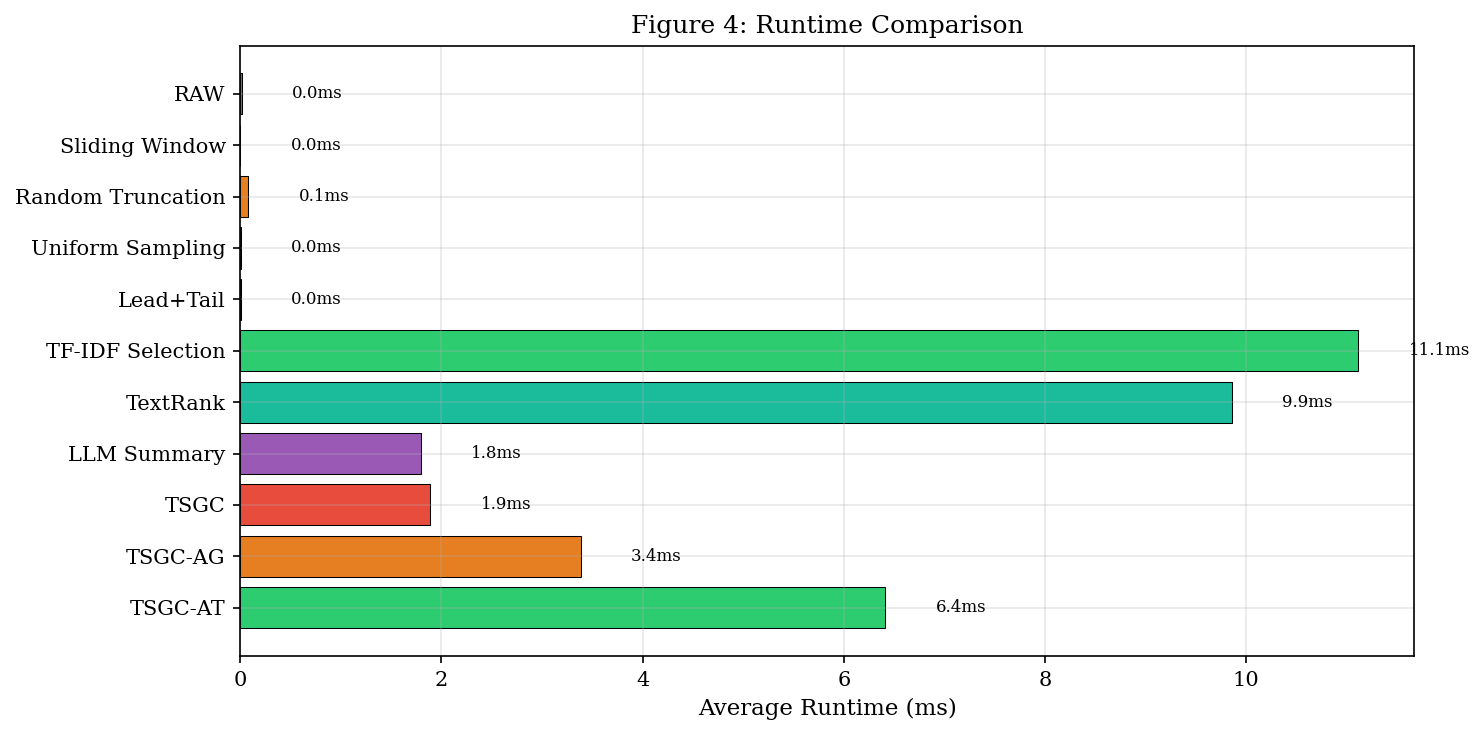

In [15]:
# ── FIGURE 4: Runtime Comparison ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
rt = df.groupby('Method')['Runtime ms'].mean().reindex([m for m in method_order if m in df['Method'].values])
bar_colors = [colors.get(m, '#333') for m in rt.index]
bars = ax.barh(rt.index, rt.values, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Average Runtime (ms)')
ax.set_title('Figure 4: Runtime Comparison')
for bar, val in zip(bars, rt.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}ms', va='center', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

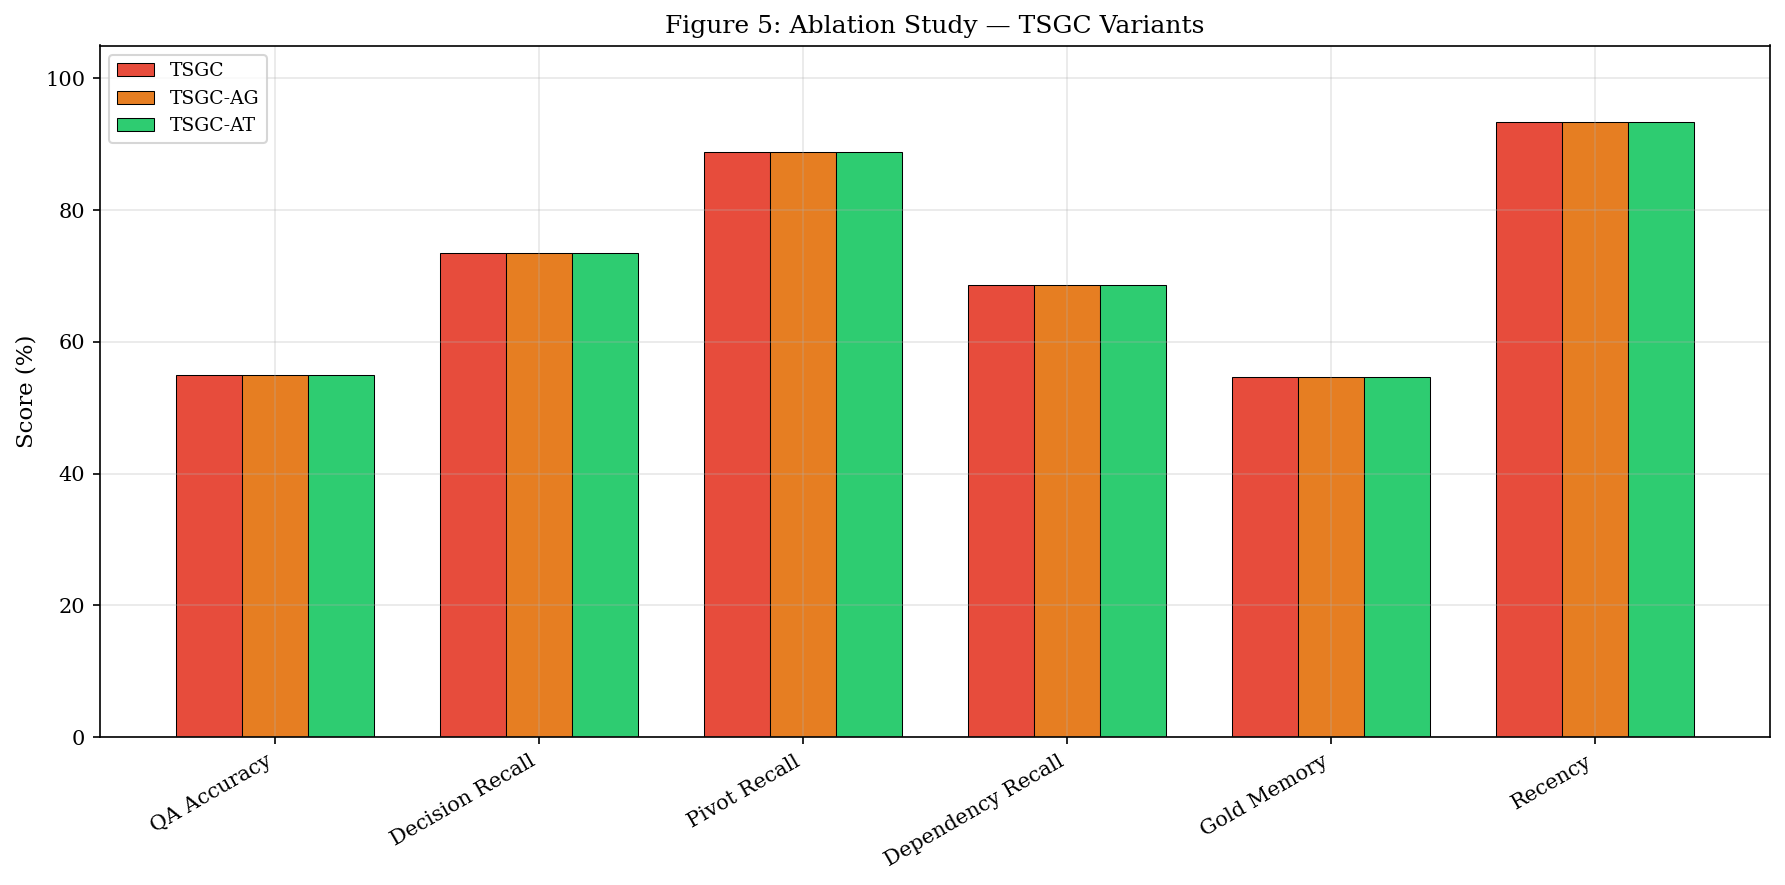

In [16]:
# ── FIGURE 5: Ablation Study — Grouped Bar ─────────────────────
ablation_metrics = ['QA Accuracy %', 'Decision Recall %', 'Pivot Recall %',
                    'Dependency Recall %', 'Gold Memory %', 'Recency %']
tsgc_only = agg.loc[[m for m in ['TSGC','TSGC-AG','TSGC-AT'] if m in agg.index]]

x = np.arange(len(ablation_metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))

tsgc_colors = {'TSGC': '#e74c3c', 'TSGC-AG': '#e67e22', 'TSGC-AT': '#2ecc71'}
for i, method in enumerate(tsgc_only.index):
    vals = [tsgc_only.loc[method][col] for col in ablation_metrics]
    ax.bar(x + i*width, vals, width, label=method, color=tsgc_colors.get(method, '#333'),
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace(' %','') for c in ablation_metrics], rotation=30, ha='right')
ax.set_ylabel('Score (%)')
ax.set_title('Figure 5: Ablation Study — TSGC Variants')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

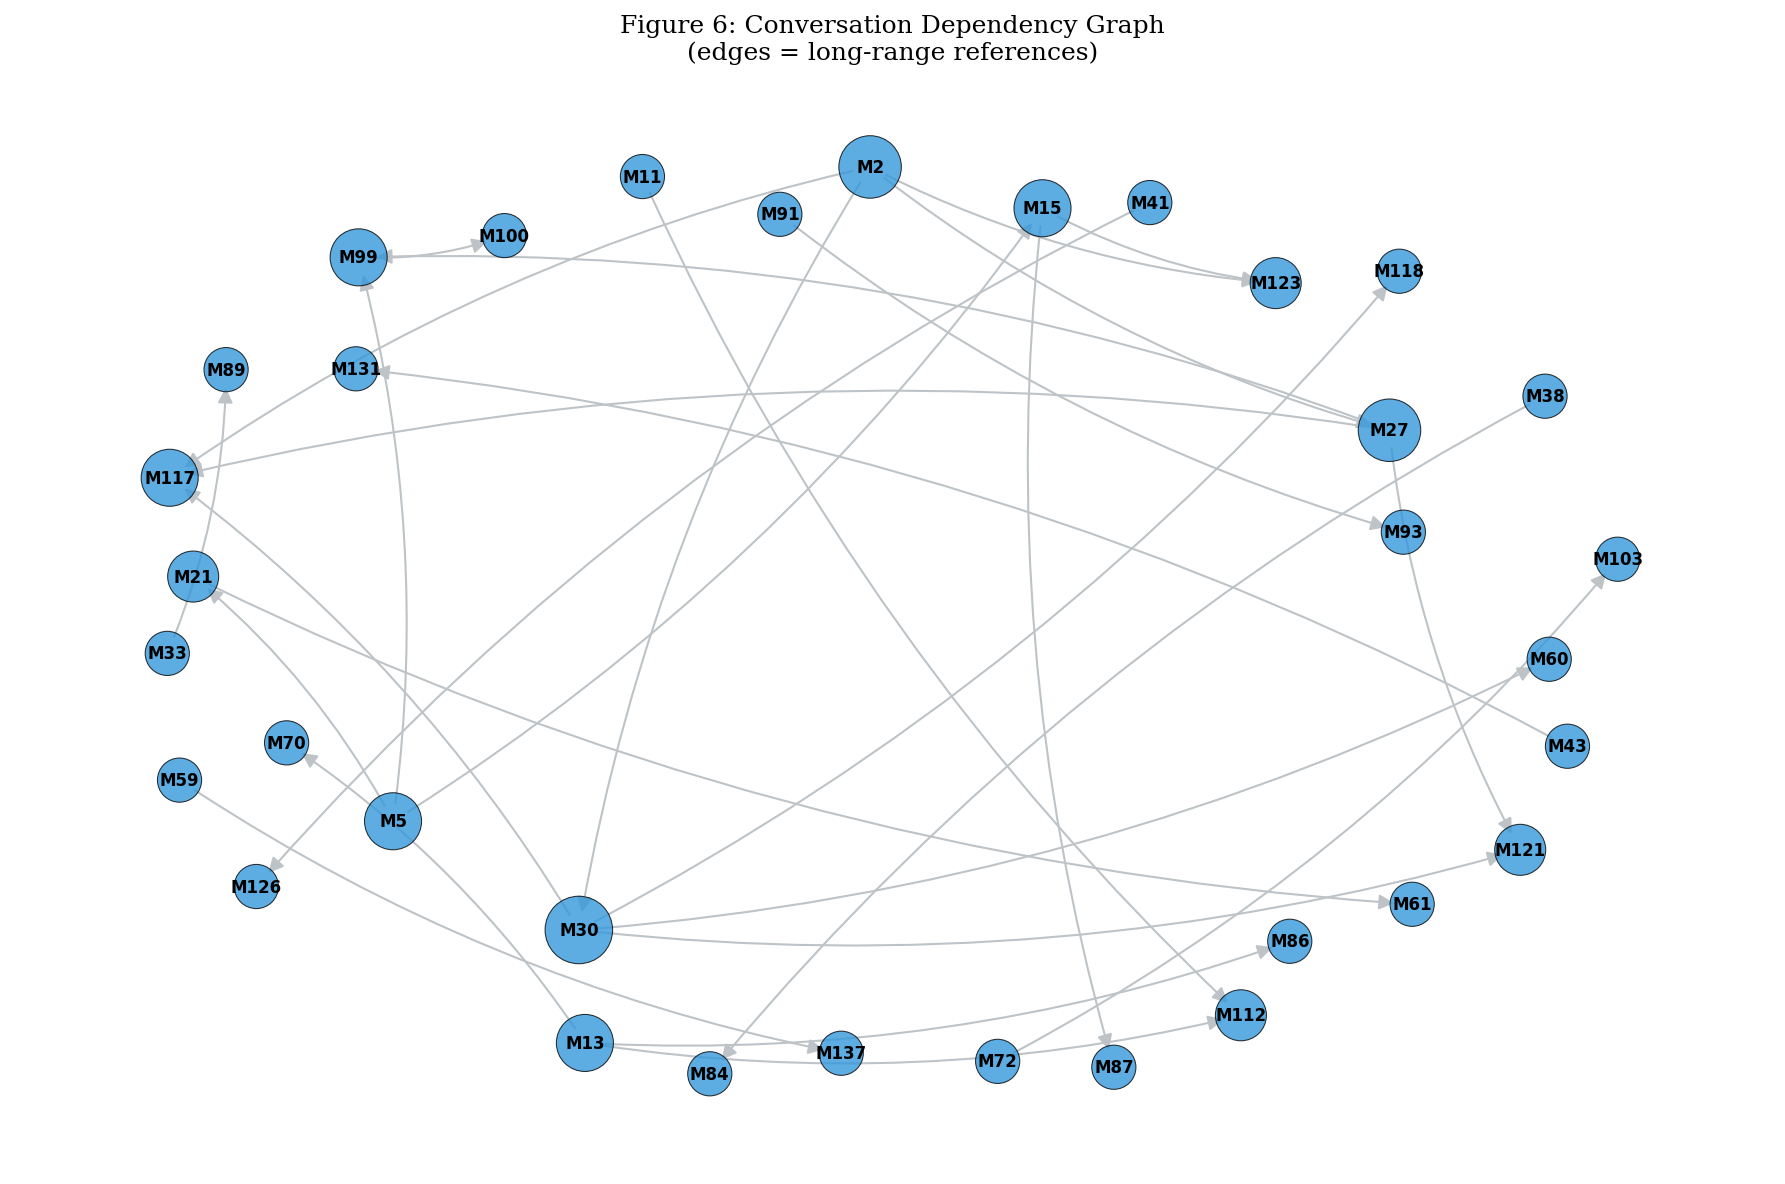

In [17]:
# ── FIGURE 6: Conversation Dependency Graph ────────────────────
deps = EVAL['part_b'].get('long_range_dependencies', [])
G = nx.DiGraph()
for dep in deps:
    src = dep.get('introduced_message', 0)
    refs = dep.get('referenced_messages', [])
    label = dep.get('description', '')[:40]
    G.add_node(src, label=f'M{src}')
    for ref in refs:
        G.add_node(ref, label=f'M{ref}')
        G.add_edge(src, ref)

if G.number_of_nodes() > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2, seed=42)
    node_sizes = [300 + G.degree(n) * 150 for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color='#3498db',
                           edgecolors='black', linewidths=0.5, alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#bdc3c7', arrows=True,
                           arrowsize=15, connectionstyle='arc3,rad=0.1')
    labels = {n: f'M{n}' for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8, font_weight='bold')
    ax.set_title('Figure 6: Conversation Dependency Graph\n(edges = long-range references)')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No dependency data to plot.")

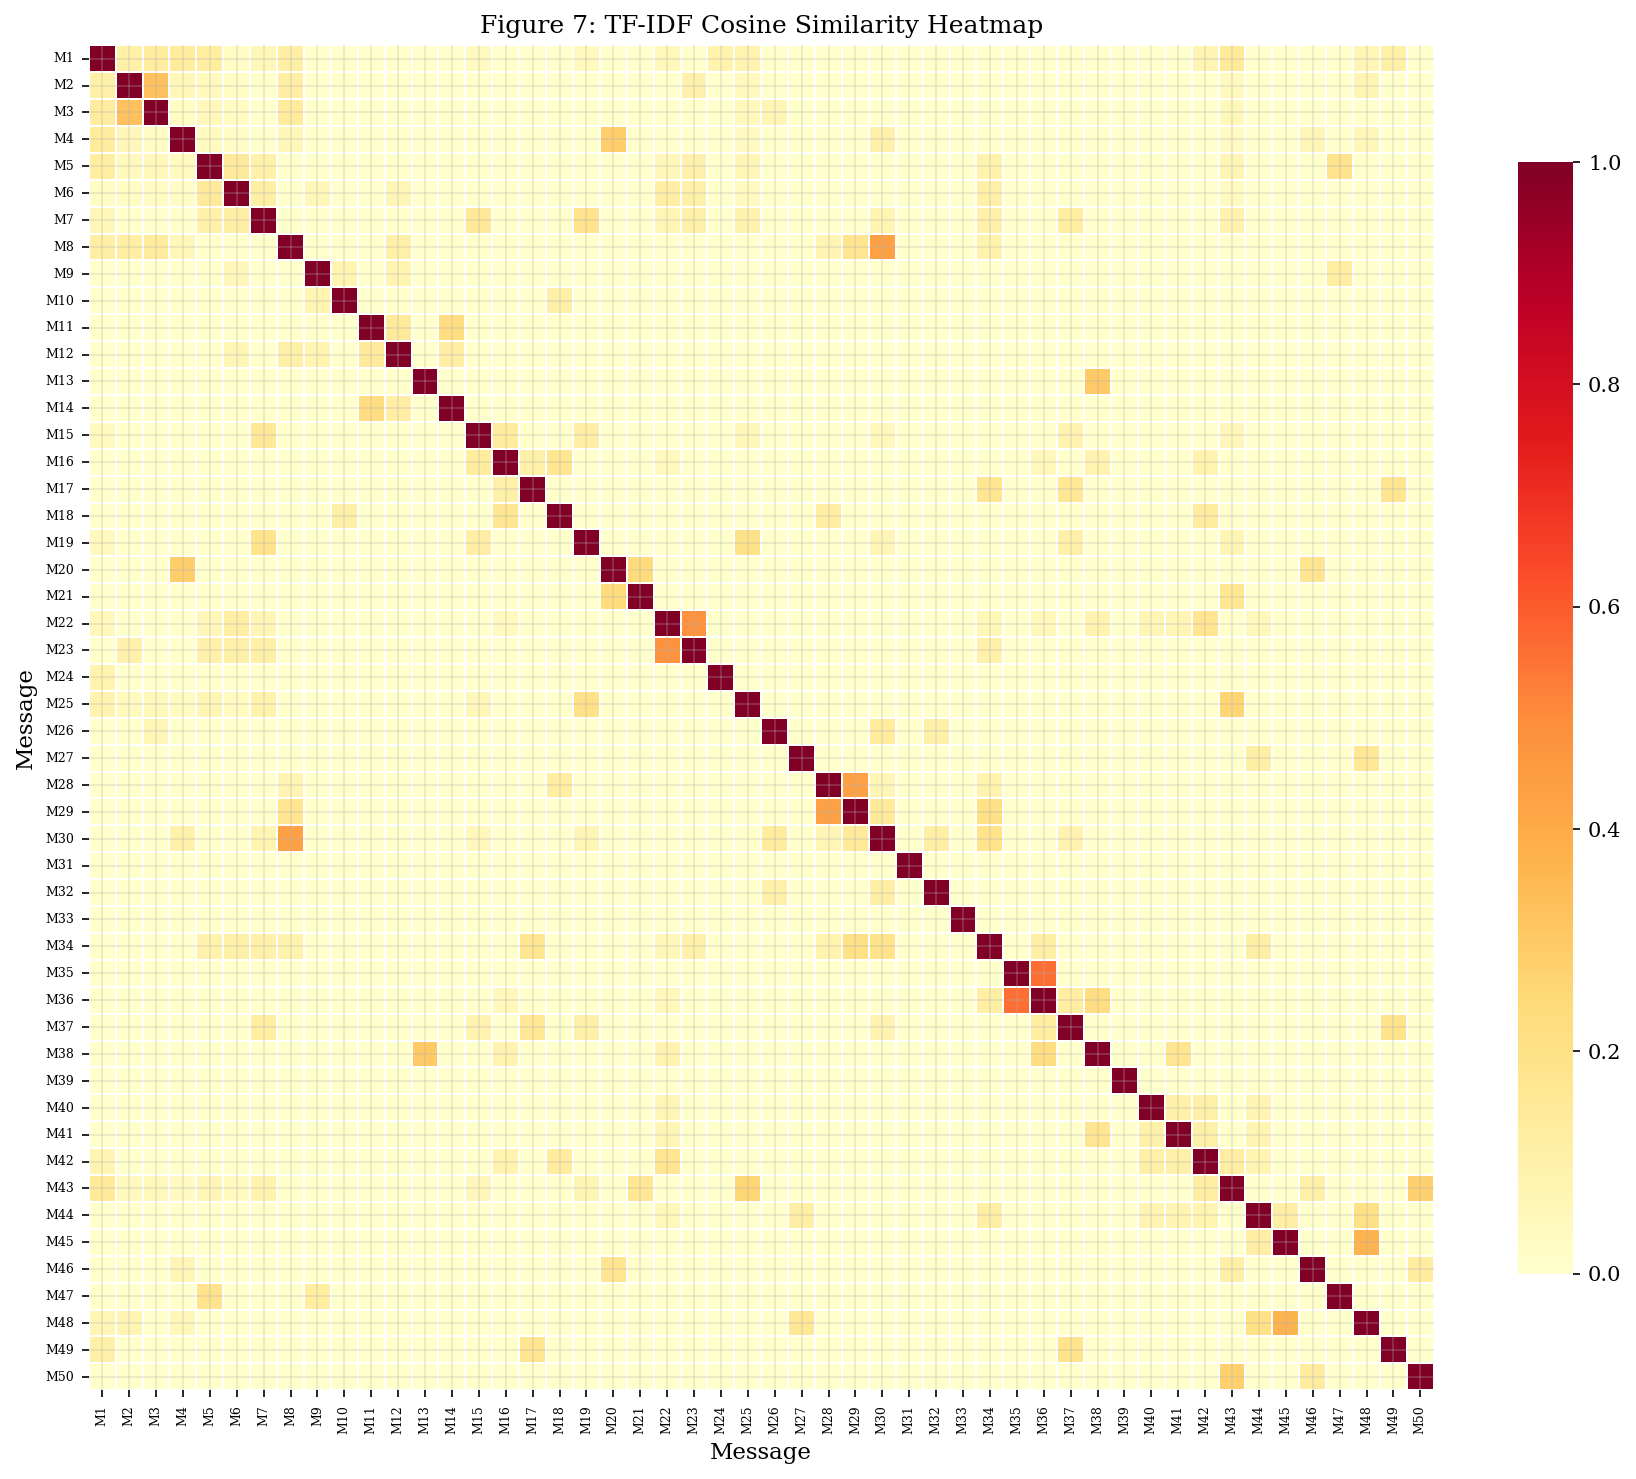

In [18]:
# ── FIGURE 7: TF-IDF Cosine Similarity Heatmap ─────────────────
conv_msgs = PRIMARY_CONV
texts = [m['content'] for m in conv_msgs]

# Sample if too many messages
if len(texts) > 50:
    step = len(texts) // 50
    sampled_idx = list(range(0, len(texts), step))[:50]
    texts_sampled = [texts[i] for i in sampled_idx]
    labels = [f'M{i+1}' for i in sampled_idx]
else:
    texts_sampled = texts
    labels = [f'M{i+1}' for i in range(len(texts))]

vec = TfidfVectorizer(max_features=500, stop_words='english')
tfidf = vec.fit_transform(texts_sampled)
sim = cosine_similarity(tfidf)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim, xticklabels=labels, yticklabels=labels, cmap='YlOrRd',
            square=True, ax=ax, cbar_kws={'shrink': 0.8},
            linewidths=0.1, linecolor='white')
ax.set_title('Figure 7: TF-IDF Cosine Similarity Heatmap')
ax.set_xlabel('Message')
ax.set_ylabel('Message')
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

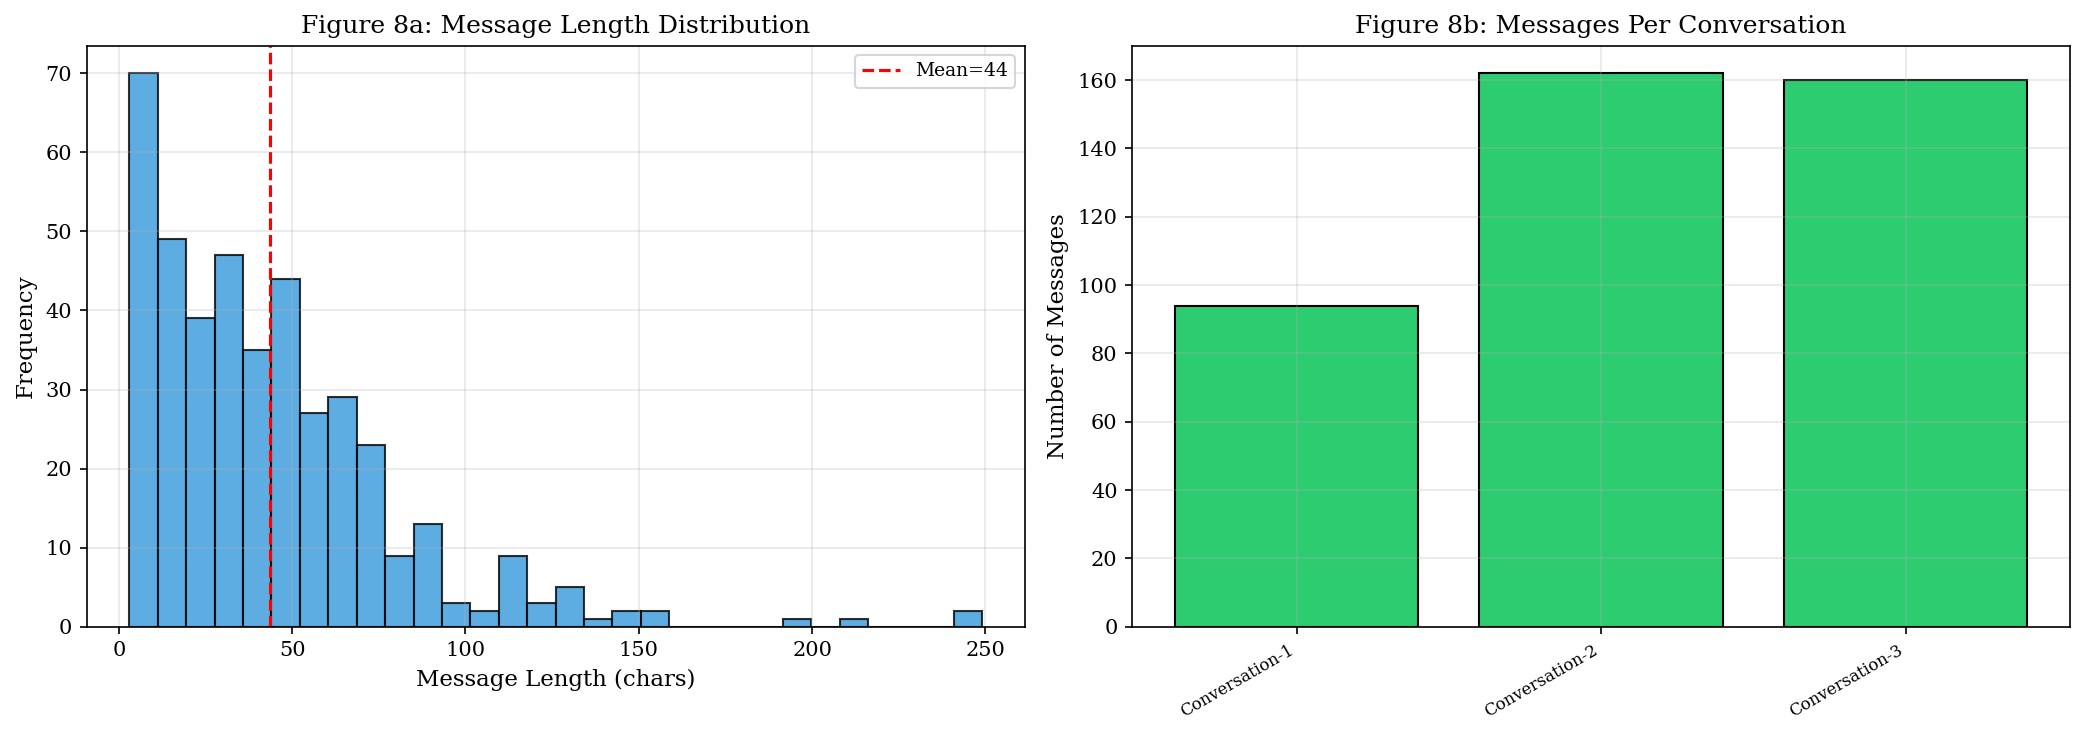

In [19]:
# ── FIGURE 8: Conversation Length Distribution ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 8a: Message lengths
all_lengths = [len(m['content']) for conv in CONVERSATIONS.values() for m in conv]
axes[0].hist(all_lengths, bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Message Length (chars)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Figure 8a: Message Length Distribution')
axes[0].axvline(np.mean(all_lengths), color='red', linestyle='--', label=f'Mean={np.mean(all_lengths):.0f}')
axes[0].legend()

# 8b: Messages per conversation
conv_sizes = {name: len(msgs) for name, msgs in CONVERSATIONS.items()}
axes[1].bar(range(len(conv_sizes)), list(conv_sizes.values()),
            color='#2ecc71', edgecolor='black')
axes[1].set_xticks(range(len(conv_sizes)))
axes[1].set_xticklabels([n[:15] for n in conv_sizes.keys()], rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('Number of Messages')
axes[1].set_title('Figure 8b: Messages Per Conversation')

plt.tight_layout()
plt.show()

In [20]:
# ── FIGURE 9: Qualitative Comparison ───────────────────────────
print('═'*90)
print('FIGURE 9: Qualitative Comparison — First 500 chars of compressed output')
print('═'*90)

compare_methods = ['RAW', 'Sliding Window', 'TSGC', 'TSGC-AT']
conv = PRIMARY_CONV

for method_name, method_fn, _ in METHODS:
    if method_name not in compare_methods:
        continue
    compressed = method_fn(conv)
    text = msgs_to_text(compressed)
    print(f'\n┌─ {method_name} ({len(compressed)} msgs, {len(text)} chars) ─')
    print(f'│ {text[:500]}')
    print(f'└─{"─"*60}')

══════════════════════════════════════════════════════════════════════════════════════════
FIGURE 9: Qualitative Comparison — First 500 chars of compressed output
══════════════════════════════════════════════════════════════════════════════════════════

┌─ RAW (94 msgs, 7566 chars) ─
│ user: I've been thinking about building a platform that lets people upload conversations from different AI assistants and continue them elsewhere without losing context. Initially it's just a side project, but I want the architecture to scale if it grows.
assistant: That's an interesting problem. The biggest challenge isn't importing conversations—it's preserving context across different assistant formats. Are you aiming for exact replay or semantic continuity?
user: Semantic continuity. Differe
└─────────────────────────────────────────────────────────────

┌─ Sliding Window (20 msgs, 1372 chars) ─
│ user: I'll start with Railway.
assistant: Good. Avoid premature infrastructure complexity.
user: I gues

/tmp/ipykernel_3885/2344751568.py:35: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/tmp/ipykernel_3885/2344751568.py:35: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


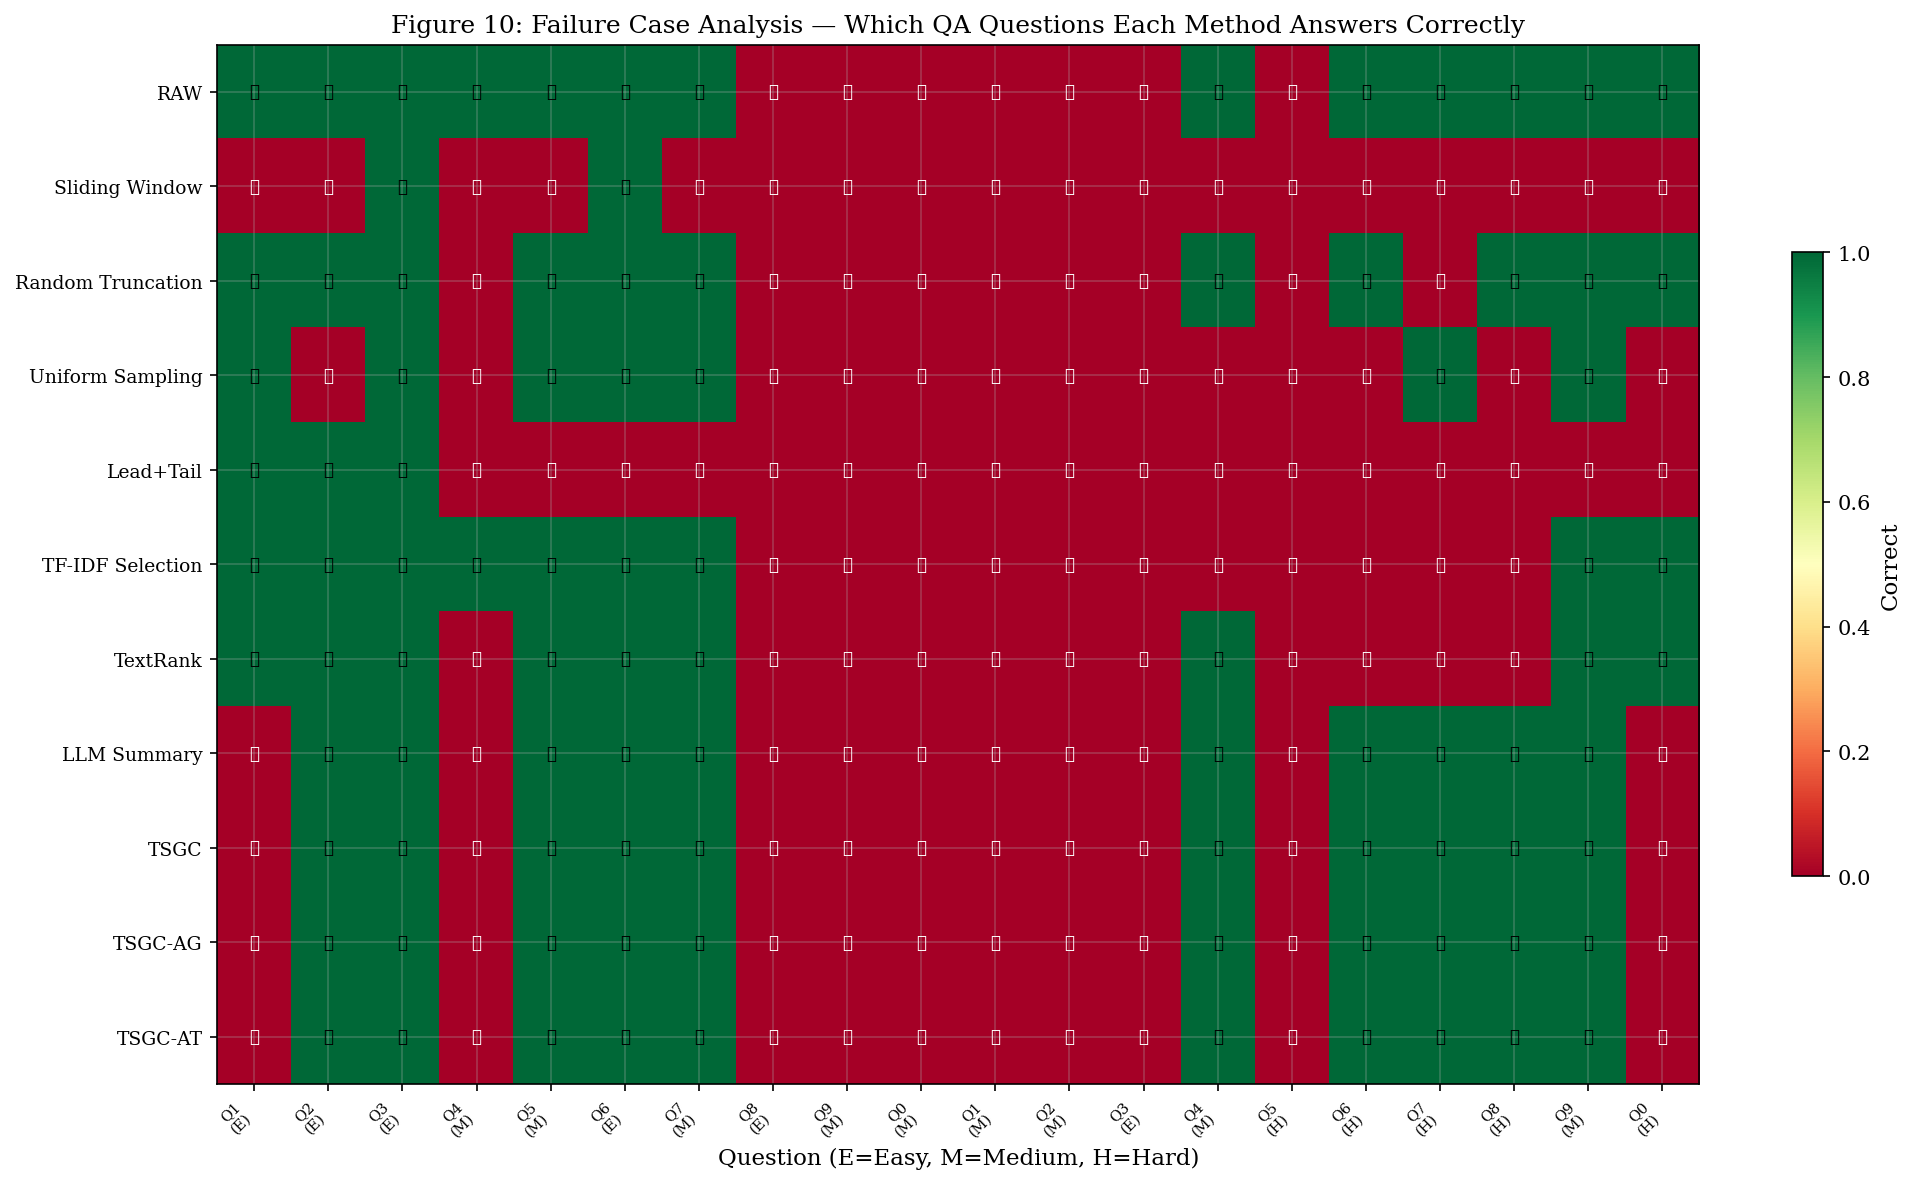

In [21]:
# ── FIGURE 10: Failure Case Analysis ───────────────────────────
qa_pairs = EVAL['part_c'].get('ground_truth_qa', [])

fig, ax = plt.subplots(figsize=(14, 8))
method_labels = []
qa_matrix = []

for method_name, method_fn, _ in METHODS:
    compressed = method_fn(PRIMARY_CONV)
    ct = msgs_to_text(compressed)
    _, details = eval_qa_accuracy(ct, qa_pairs)
    row = [1 if details.get(qa['id'], {}).get('passed', False) else 0 for qa in qa_pairs]
    qa_matrix.append(row)
    method_labels.append(method_name)

qa_matrix = np.array(qa_matrix)
qa_labels = [f"Q{qa['id'][-1] if len(qa['id'])>1 else qa['id']}\n({qa['difficulty'][0]})" for qa in qa_pairs]

im = ax.imshow(qa_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(qa_labels)))
ax.set_xticklabels(qa_labels, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(method_labels)))
ax.set_yticklabels(method_labels, fontsize=9)
ax.set_title('Figure 10: Failure Case Analysis — Which QA Questions Each Method Answers Correctly')
ax.set_xlabel('Question (E=Easy, M=Medium, H=Hard)')

# Add text
for i in range(len(method_labels)):
    for j in range(len(qa_pairs)):
        ax.text(j, i, '✓' if qa_matrix[i,j] else '✗',
                ha='center', va='center', fontsize=8,
                color='white' if qa_matrix[i,j] == 0 else 'black')

plt.colorbar(im, ax=ax, shrink=0.6, label='Correct')
plt.tight_layout()
plt.show()

## 8. Summary & References

In [22]:
# ── FINAL SUMMARY ──────────────────────────────────────────────
print('═'*100)
print('TSGC BENCHMARK v2 — GROUND-TRUTH EVALUATION SUMMARY')
print('═'*100)
print(f'\nDataset: {len(CONVERSATIONS)} conversations, {sum(len(c) for c in CONVERSATIONS.values())} total messages')
print(f'Evaluation: {len(EVAL["part_c"].get("ground_truth_qa",[]))} QA pairs, '
      f'{len(EVAL["part_a"].get("major_decisions",[]))} decisions, '
      f'{len(EVAL["part_d"].get("gold_memory",[]))} gold memory items')
print()

# Best method per metric
print('BEST METHOD PER METRIC (excluding RAW):')
print('─'*60)
non_raw = agg.drop('RAW', errors='ignore')
for col in metric_cols:
    if col == 'Runtime ms':
        best = non_raw[col].idxmin()
        print(f'  {col:25} → {best} ({non_raw.loc[best][col]:.1f})')
    else:
        best = non_raw[col].idxmax()
        print(f'  {col:25} → {best} ({non_raw.loc[best][col]:.1f}%)')

print()
print('TSGC FAMILY COMPARISON:')
print('─'*60)
for m in ['TSGC', 'TSGC-AG', 'TSGC-AT']:
    if m in agg.index:
        r = agg.loc[m]
        print(f'  {m:10}  Comp:{r["Compression %"]:5.1f}%  QA:{r["QA Accuracy %"]:5.1f}%  '
              f'Gold:{r["Gold Memory %"]:5.1f}%  Pivot:{r["Pivot Recall %"]:5.1f}%  '
              f'Deps:{r["Dependency Recall %"]:5.1f}%')

print('\n' + '═'*100)
print('REFERENCES')
print('─'*100)
for r in [
    '[1] Deutsch, P. (1996). DEFLATE Compressed Data Format Specification. RFC 1951.',
    '[2] Mihalcea & Tarau (2004). TextRank: Bringing Order into Texts. EMNLP 2004.',
    '[3] Jiang et al. (2023). LLMLingua: Compressing Prompts for Accelerated Inference. arXiv:2310.05736.',
    '[4] Vaswani et al. (2017). Attention Is All You Need. NeurIPS 2017.',
    '[5] Hochreiter & Schmidhuber (1997). Long Short-Term Memory. Neural Computation.',
    '[6] Reyna & Brainerd (1995). Fuzzy-trace theory. Learning and Individual Differences.',
    '[7] Salton & McGill (1983). Introduction to Modern Information Retrieval. (TF-IDF)',
    '[8] Page et al. (1999). The PageRank Citation Ranking. Stanford InfoLab. (TextRank basis)',
]: print(r)

════════════════════════════════════════════════════════════════════════════════════════════════════
TSGC BENCHMARK v2 — GROUND-TRUTH EVALUATION SUMMARY
════════════════════════════════════════════════════════════════════════════════════════════════════

Dataset: 3 conversations, 416 total messages
Evaluation: 20 QA pairs, 29 decisions, 25 gold memory items

BEST METHOD PER METRIC (excluding RAW):
────────────────────────────────────────────────────────────
  Compression %             → Sliding Window (84.9%)
  QA Accuracy %             → LLM Summary (55.0%)
  Decision Recall %         → TF-IDF Selection (74.7%)
  Entity Recall %           → LLM Summary (53.8%)
  Pivot Recall %            → LLM Summary (88.9%)
  Dependency Recall %       → TF-IDF Selection (70.6%)
  Gold Memory %             → LLM Summary (54.7%)
  Topic Preservation %      → TF-IDF Selection (69.2%)
  Recency %                 → Sliding Window (100.0%)
  Runtime ms                → Sliding Window (0.0)

TSGC FAMILY CO